# Chapter 11. QAOA — Max-Cut 조합 최적화

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- 작은 그래프의 Max-Cut Hamiltonian 직접 작성
- QAOA 회로 (cost / mixer 교대) 구현
- 학습된 회로에서 비트열을 샘플링해 최적 분할 찾기

In [2]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from itertools import product

## 11.1 그래프와 Max-Cut Hamiltonian
4-노드 그래프에서 Max-Cut을 정의한다.
각 엣지 (i,j)에 대해 cost 연산자는 (I - Z_i Z_j) / 2 이고, 이를 합해 최대화한다.

In [3]:
# 엣지 리스트로 그래프 정의
edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]
n_qubits = 4

# Cost Hamiltonian: -sum_{(i,j)} (I - Z_i Z_j) / 2 (음수로 최대화 → 최소화 문제)
coeffs = []
obs = []
for i, j in edges:
    coeffs.extend([-0.5, 0.5])
    obs.extend([qml.Identity(0), qml.PauliZ(i) @ qml.PauliZ(j)])
H_cost = qml.Hamiltonian(coeffs, obs)
print(H_cost)

-0.5 * I(0) + 0.5 * (Z(0) @ Z(1)) + -0.5 * I(0) + 0.5 * (Z(0) @ Z(2)) + -0.5 * I(0) + 0.5 * (Z(1) @ Z(2)) + -0.5 * I(0) + 0.5 * (Z(1) @ Z(3)) + -0.5 * I(0) + 0.5 * (Z(2) @ Z(3))


## 11.2 QAOA 회로
교대 적용: $e^{-iγ H_C} → e^{-iβ H_M}$, P회 반복

In [4]:
dev = qml.device('default.qubit', wires=n_qubits)
P = 3  # QAOA 깊이 (layers)

@qml.qnode(dev, interface='autograd')
def qaoa_circuit(params):
    # params = [gamma_1, beta_1, gamma_2, beta_2, ...]
    # 초기 상태: 모든 큐비트 Hadamard (|+>^n)
    for w in range(n_qubits):
        qml.Hadamard(wires=w)
    # P회 교대
    for layer in range(P):
        gamma = params[2 * layer]
        beta = params[2 * layer + 1]
        # Cost layer
        for i, j in edges:
            qml.MultiRZ(2 * gamma, wires=[i, j])
        # Mixer layer
        for w in range(n_qubits):
            qml.RX(2 * beta, wires=w)
    return qml.expval(H_cost)

## 11.3 학습
음의 cost를 최소화 → 양의 cost를 최대화

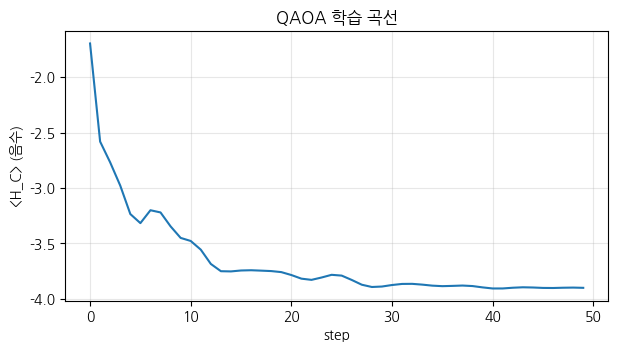

최종 <H_C> = -3.9004
학습된 gammas: [1.28191699 2.35293642 1.31121411]
학습된 betas:  [1.9037057  1.25318579 2.61243455]


In [5]:
rng = np.random.RandomState(0)
params = pnp.array(rng.uniform(0, np.pi, 2 * P), requires_grad=True)
opt = qml.AdamOptimizer(0.1)

history = []
for step in range(50):
    params, c = opt.step_and_cost(qaoa_circuit, params)
    history.append(c)

plt.figure(figsize=(7, 3.5))
plt.plot(history)
plt.xlabel('step'); plt.ylabel('<H_C> (음수)')
plt.title('QAOA 학습 곡선')
plt.grid(alpha=0.3)
plt.show()
print(f'최종 <H_C> = {history[-1]:.4f}')
print(f'학습된 gammas: {params[::2]}')
print(f'학습된 betas:  {params[1::2]}')

## 11.4 비트열 샘플링과 최적 분할 찾기
학습된 QAOA 회로에서 측정 분포를 본다.

In [6]:
@qml.qnode(dev)
def sample_circuit(params):
    for w in range(n_qubits):
        qml.Hadamard(wires=w)
    for layer in range(P):
        gamma = params[2 * layer]
        beta = params[2 * layer + 1]
        for i, j in edges:
            qml.MultiRZ(2 * gamma, wires=[i, j])
        for w in range(n_qubits):
            qml.RX(2 * beta, wires=w)
    return qml.probs(wires=range(n_qubits))

probs = sample_circuit(params)

# 비트열별 cut 값 계산
def cut_value(bitstring):
    return sum(1 for i, j in edges if bitstring[i] != bitstring[j])

bitstrings = [''.join(b) for b in product('01', repeat=n_qubits)]
cuts = [cut_value([int(c) for c in b]) for b in bitstrings]

# 확률이 가장 큰 비트열 출력
top_idx = np.argsort(probs)[::-1][:5]
header = ('bitstring', 'prob', 'cut_value')
print(f'{header[0]:<12}{header[1]:<10}{header[2]}')
print('-' * 32)
for i in top_idx:
    print(f'{bitstrings[i]:<12}{probs[i]:<10.4f}{cuts[i]}')

max_cut = max(cuts)
print(f'\n최대 cut 값 (정답): {max_cut}')

bitstring   prob      cut_value
--------------------------------
1001        0.4765    4
0110        0.4765    4
1111        0.0083    0
0000        0.0083    0
1100        0.0059    3

최대 cut 값 (정답): 4


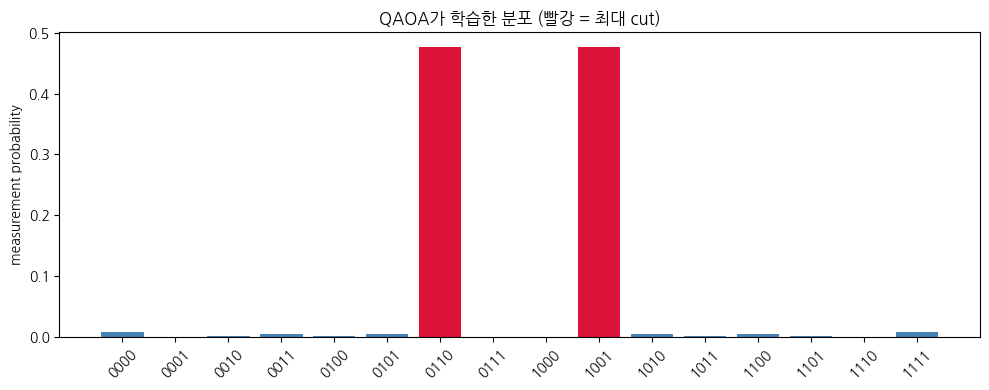

In [7]:
# 모든 비트열의 확률 분포 시각화
plt.figure(figsize=(10, 4))
colors = ['crimson' if cuts[i] == max_cut else 'steelblue' for i in range(len(bitstrings))]
plt.bar(bitstrings, probs, color=colors)
plt.xticks(rotation=45)
plt.ylabel('measurement probability')
plt.title('QAOA가 학습한 분포 (빨강 = 최대 cut)')
plt.tight_layout()
plt.show()

## 11.5 정리
- QAOA = cost/mixer 유니터리의 교대 적용
- 학습 후 회로에서 샘플링하면 최적 비트열이 높은 확률로 나옴
- 깊이 P가 클수록 정확도가 올라가지만 학습은 어려워짐